In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/m5_model_df_small.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["id", "date"]).reset_index(drop=True)

print("Rows:", len(df), "Unique series:", df["id"].nunique())
print(df["date"].min(), "to", df["date"].max())


Rows: 365500 Unique series: 500
2014-04-25 00:00:00 to 2016-04-24 00:00:00


In [2]:
HORIZON = 28
max_date = df["date"].max()
val_start = max_date - pd.Timedelta(days=HORIZON - 1)

train_df = df[df["date"] < val_start].copy()
val_df = df[df["date"] >= val_start].copy()

print("Train:", train_df["date"].min(), "to", train_df["date"].max(), "| rows:", len(train_df))
print("Val:  ", val_df["date"].min(), "to", val_df["date"].max(), "| rows:", len(val_df))


Train: 2014-04-25 00:00:00 to 2016-03-27 00:00:00 | rows: 351500
Val:   2016-03-28 00:00:00 to 2016-04-24 00:00:00 | rows: 14000


In [3]:
# Helper: get last observed sales in train for each id
last_sales = train_df.groupby("id")["sales"].last()

# Helper: build a lookup table of past sales by (id, date) for seasonal naive
train_sales_lookup = train_df.set_index(["id", "date"])["sales"]

val_pred = val_df[["id", "date", "sales"]].copy()

# 1) Naive: yesterday's sales (using last train day for first val day)
# We'll approximate naive for each day in val by shifting actuals within val, seeded by last train value.
val_pred["pred_naive"] = np.nan

for series_id, grp in val_pred.groupby("id"):
    grp = grp.sort_values("date")
    # seed with last train value
    seed = last_sales.get(series_id, 0.0)
    shifted = grp["sales"].shift(1)
    shifted.iloc[0] = seed
    val_pred.loc[grp.index, "pred_naive"] = shifted.values

# 2) Seasonal naive (7-day): use sales from t-7
# For dates where t-7 is in train, use that; else fallback to naive
val_pred["pred_seasonal_7"] = np.nan

for i, row in val_pred.iterrows():
    key = (row["id"], row["date"] - pd.Timedelta(days=7))
    val_pred.at[i, "pred_seasonal_7"] = train_sales_lookup.get(key, np.nan)

# fill missing seasonal values with naive
val_pred["pred_seasonal_7"] = val_pred["pred_seasonal_7"].fillna(val_pred["pred_naive"])

# 3) Moving average (28-day): mean of last 28 days of train for each series
ma28 = train_df.groupby("id")["sales"].tail(28).groupby(train_df.groupby("id").tail(28)["id"]).mean()
val_pred["pred_ma_28"] = val_pred["id"].map(ma28).fillna(last_sales).fillna(0.0)

val_pred.head()


,id,date,sales,pred_naive,pred_seasonal_7,pred_ma_28
703,FOODS_1_004_CA_1_validation,2016-03-28,0,0.0,0.0,0.0
704,FOODS_1_004_CA_1_validation,2016-03-29,0,0.0,0.0,0.0
705,FOODS_1_004_CA_1_validation,2016-03-30,0,0.0,0.0,0.0
706,FOODS_1_004_CA_1_validation,2016-03-31,0,0.0,0.0,0.0
707,FOODS_1_004_CA_1_validation,2016-04-01,0,0.0,0.0,0.0


In [4]:
def mae(y, yhat):
    return np.mean(np.abs(y - yhat))

def rmse(y, yhat):
    return np.sqrt(np.mean((y - yhat) ** 2))

def wape(y, yhat):
    denom = np.sum(np.abs(y))
    return np.sum(np.abs(y - yhat)) / denom if denom != 0 else np.nan

y = val_pred["sales"].values

results = []
for col in ["pred_naive", "pred_seasonal_7", "pred_ma_28"]:
    yhat = val_pred[col].values
    results.append({
        "model": col,
        "MAE": mae(y, yhat),
        "RMSE": rmse(y, yhat),
        "WAPE": wape(y, yhat)
    })

results_df = pd.DataFrame(results).sort_values("WAPE")
results_df


,model,MAE,RMSE,WAPE
2,pred_ma_28,4.438276,7.159490,0.497139
0,pred_naive,4.578357,7.654938,0.512829
1,pred_seasonal_7,4.651857,7.631214,0.521062


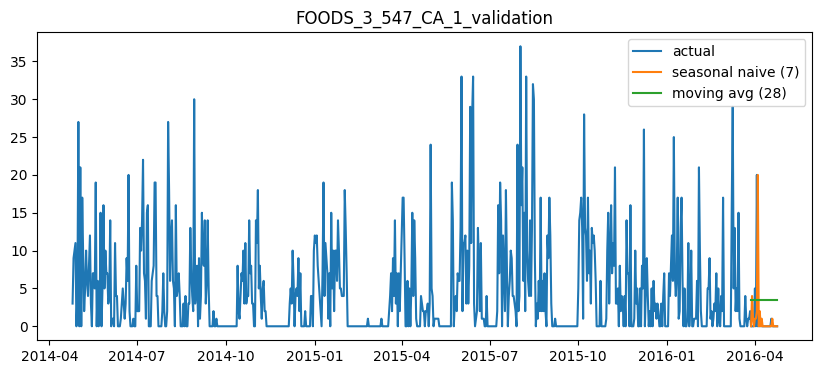

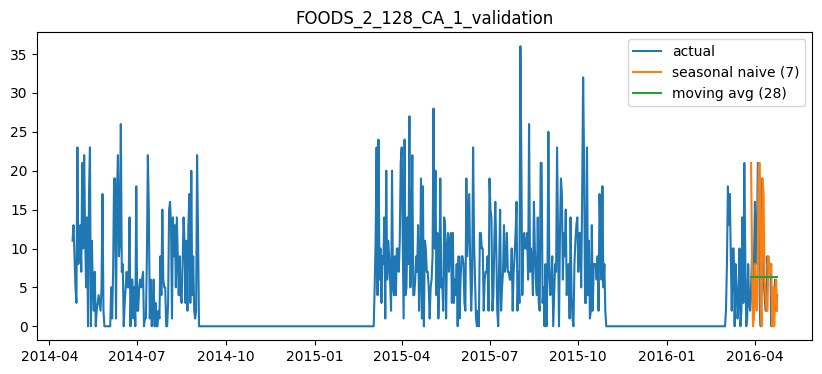

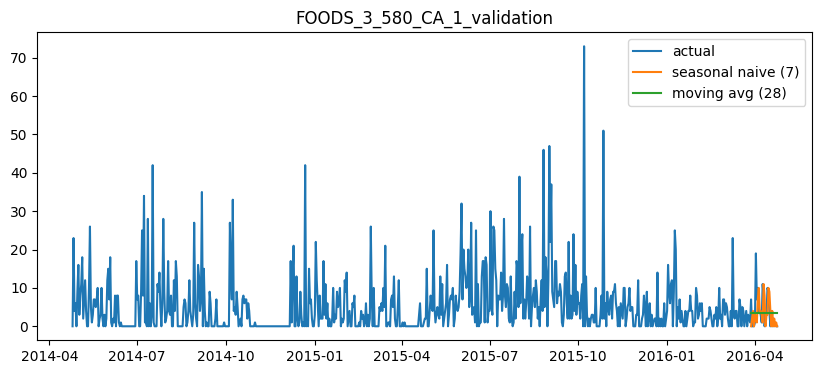

In [5]:
sample_ids = df["id"].drop_duplicates().sample(3, random_state=42).tolist()

for series_id in sample_ids:
    hist = df[df["id"] == series_id].sort_values("date")
    valp = val_pred[val_pred["id"] == series_id].sort_values("date")

    plt.figure(figsize=(10,4))
    plt.plot(hist["date"], hist["sales"], label="actual")
    plt.plot(valp["date"], valp["pred_seasonal_7"], label="seasonal naive (7)")
    plt.plot(valp["date"], valp["pred_ma_28"], label="moving avg (28)")
    plt.title(series_id)
    plt.legend()
    plt.show()
